In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: xlabel='HeartDisease'>

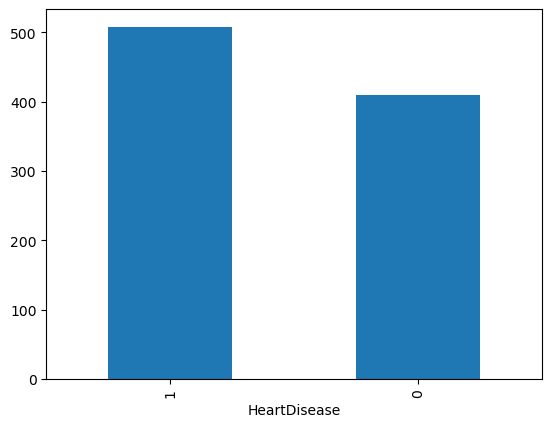

In [5]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [6]:
def ploting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
    

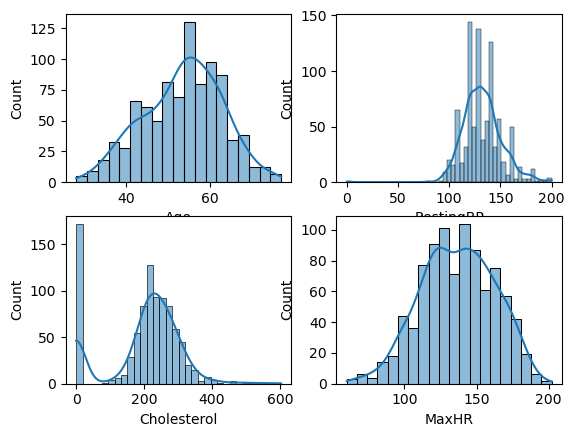

In [7]:
ploting('Age',1)
ploting('RestingBP',2)
ploting('Cholesterol',3)
ploting('MaxHR',4)

In [8]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [9]:
ch_mean = df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [10]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)

In [11]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
185      1
98       1
92       1
113      1
164      1
Name: count, Length: 67, dtype: int64

In [12]:
BP_mean = df.loc[df['RestingBP']!=0, 'RestingBP'].mean()

In [13]:
BP_mean

np.float64(132.54089422028352)

In [14]:
df['RestingBP'] = df['RestingBP'].replace(0,BP_mean)

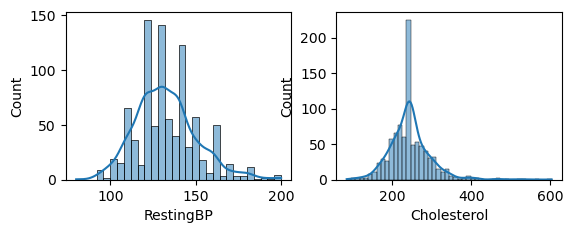

In [15]:
ploting('RestingBP',1)
ploting('Cholesterol',2)

<Axes: xlabel='Sex', ylabel='count'>

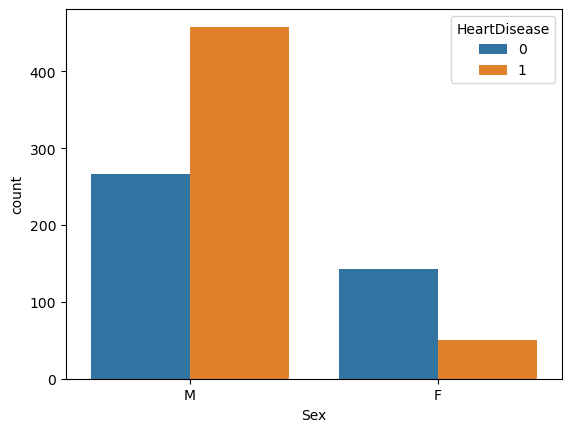

In [16]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

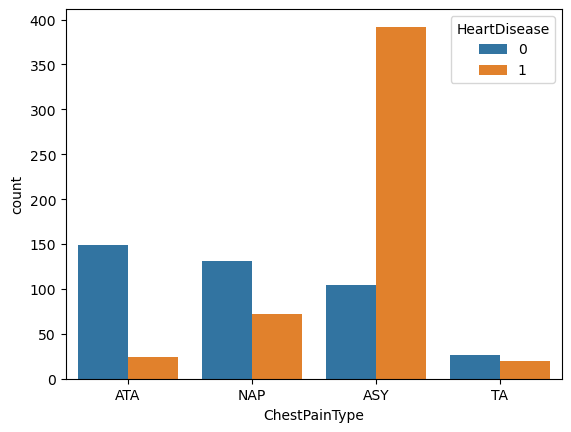

In [17]:
sns.countplot(x = df['ChestPainType'],hue = df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

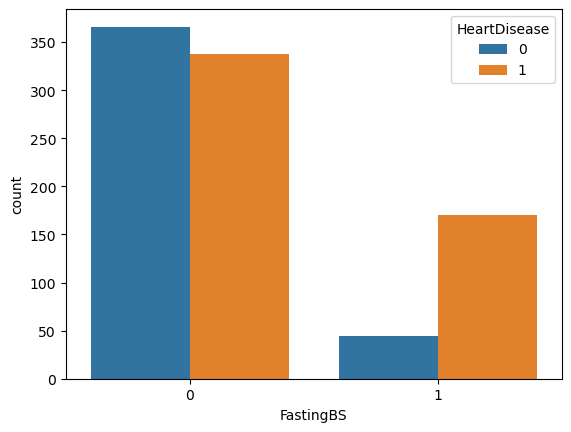

In [18]:
sns.countplot(x = df['FastingBS'],hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

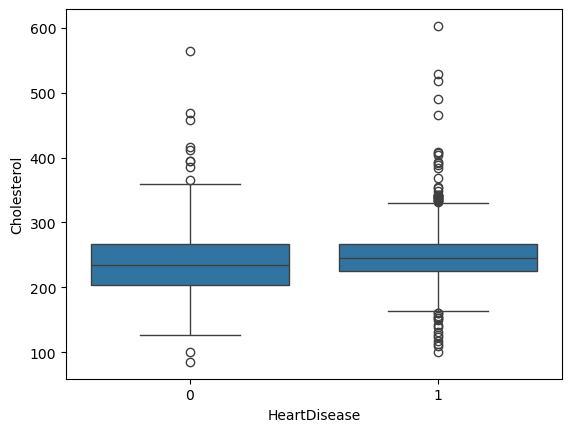

In [19]:
sns.boxplot(x=df['HeartDisease'], y=df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

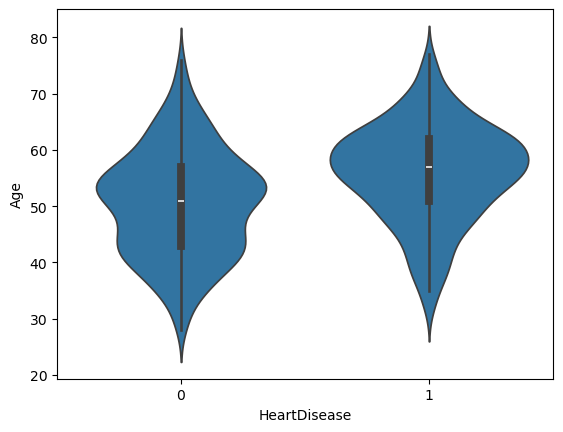

In [20]:
sns.violinplot(x=df['HeartDisease'],y=df['Age'])

<Axes: >

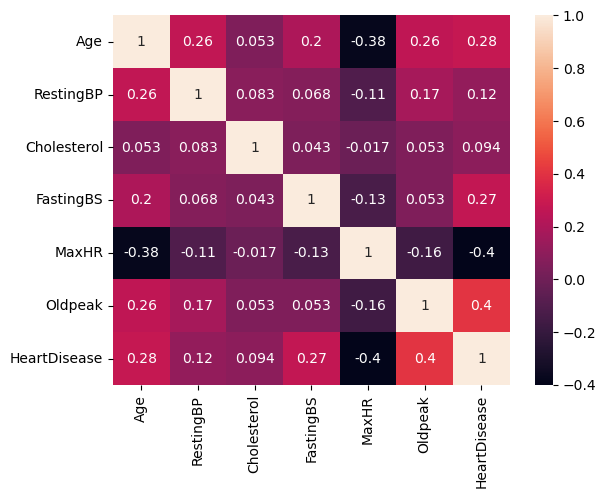

In [21]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [22]:
encode_df = pd.get_dummies(df,drop_first=True)

In [23]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [24]:
encode_df


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [25]:
bool_col = encode_df.select_dtypes(include='bool').columns

In [26]:
encode_df[bool_col]= encode_df[bool_col].astype(int)

In [27]:
encode_df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [28]:
encode_df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [29]:
from sklearn.model_selection import train_test_split

In [30]:
x = encode_df.drop('HeartDisease',axis=1)
y= encode_df['HeartDisease']

In [31]:
X_train, X_test,Y_train,Y_test = train_test_split(x,y,test_size=.4,random_state=42) 

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report,f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [33]:
scaler = StandardScaler()
col= ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

In [34]:
X_train[col] = scaler.fit_transform(X_train[col])
X_test[col] = scaler.transform(X_test[col])
X_train

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
462,0.575079,-0.628102,-0.231942,0,-0.829025,0.364049,1,0,0,0,1,0,1,0,0
433,-0.784199,-1.305406,-0.172638,0,-0.502520,1.004337,1,0,0,0,1,0,1,1,0
163,-1.202438,-0.740986,-0.963358,0,0.517807,-0.825056,1,1,0,0,1,0,0,0,1
248,-0.888759,-0.176565,-0.508694,0,-0.298455,0.089640,1,0,0,0,0,1,1,1,0
582,1.620678,-0.628102,-0.567998,1,-2.175856,-0.825056,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.575079,-0.740986,0.183186,0,-1.114716,-0.825056,0,0,0,0,0,1,0,0,1
270,-0.888759,-0.740986,-0.390086,0,0.109676,-0.825056,1,0,0,0,1,0,0,0,1
860,0.679639,-0.176565,0.163418,0,0.272928,0.455519,1,0,0,0,1,0,1,0,1
435,0.679639,1.065160,-0.001934,0,-0.788212,-0.825056,1,0,0,0,0,1,1,0,1


In [35]:
X_test[col].head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
668,0.993319,0.387855,-0.983126,1.701386,-0.825056
30,-0.052280,0.670066,5.401940,-0.298455,-0.825056
377,1.202438,1.516697,-0.001934,-0.624959,0.272580
535,0.261400,-0.176565,-0.001934,-0.624959,0.089640
807,0.052280,-1.418291,1.270426,0.762685,-0.825056


In [36]:
model_log = LogisticRegression()

In [37]:
model_log.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
y_pred_log = model_log.predict(X_test)

In [39]:
accuracy_score(Y_test,y_pred_log)

0.8614130434782609

In [40]:
confusion_matrix(Y_test,y_pred_log)

array([[131,  16],
       [ 35, 186]])

In [43]:
print(classification_report(Y_test,y_pred_log))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       147
           1       0.92      0.84      0.88       221

    accuracy                           0.86       368
   macro avg       0.85      0.87      0.86       368
weighted avg       0.87      0.86      0.86       368



In [101]:
models ={
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(kernel='rbf'),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()

}

In [102]:
results =[]

In [103]:
for name,model in models.items():
    model.fit(X_train,Y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(Y_test,y_pred)
    f1 = f1_score(Y_test,y_pred)
    results.append({'name':name,'acc':acc,'f1':f1})

In [105]:
results

[{'name': 'Logistic Regression',
  'acc': 0.8614130434782609,
  'f1': 0.8794326241134752},
 {'name': 'Decision Tree',
  'acc': 0.7445652173913043,
  'f1': 0.7772511848341233},
 {'name': 'SVM', 'acc': 0.8614130434782609, 'f1': 0.8811188811188811},
 {'name': 'Naive Bayes', 'acc': 0.8505434782608695, 'f1': 0.8687350835322196},
 {'name': 'KNN', 'acc': 0.8614130434782609, 'f1': 0.8822170900692841}]

In [108]:
import joblib
joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']